In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
import cartopy
import cartopy.crs as ccrs
import colorcet as cc

import matplotlib
import matplotlib.font_manager as fm
font_path = '/n/home12/mhe/.cache/matplotlib/Helvetica.ttf'
fm.fontManager.addfont(font_path)
matplotlib.rcParams['font.family'] = 'Helvetica'

title_font_path = '/n/home12/mhe/.cache/matplotlib/Helvetica-Bold.ttf'
title_font = fm.FontProperties(fname=title_font_path)

### Sectoral attribution pie chart

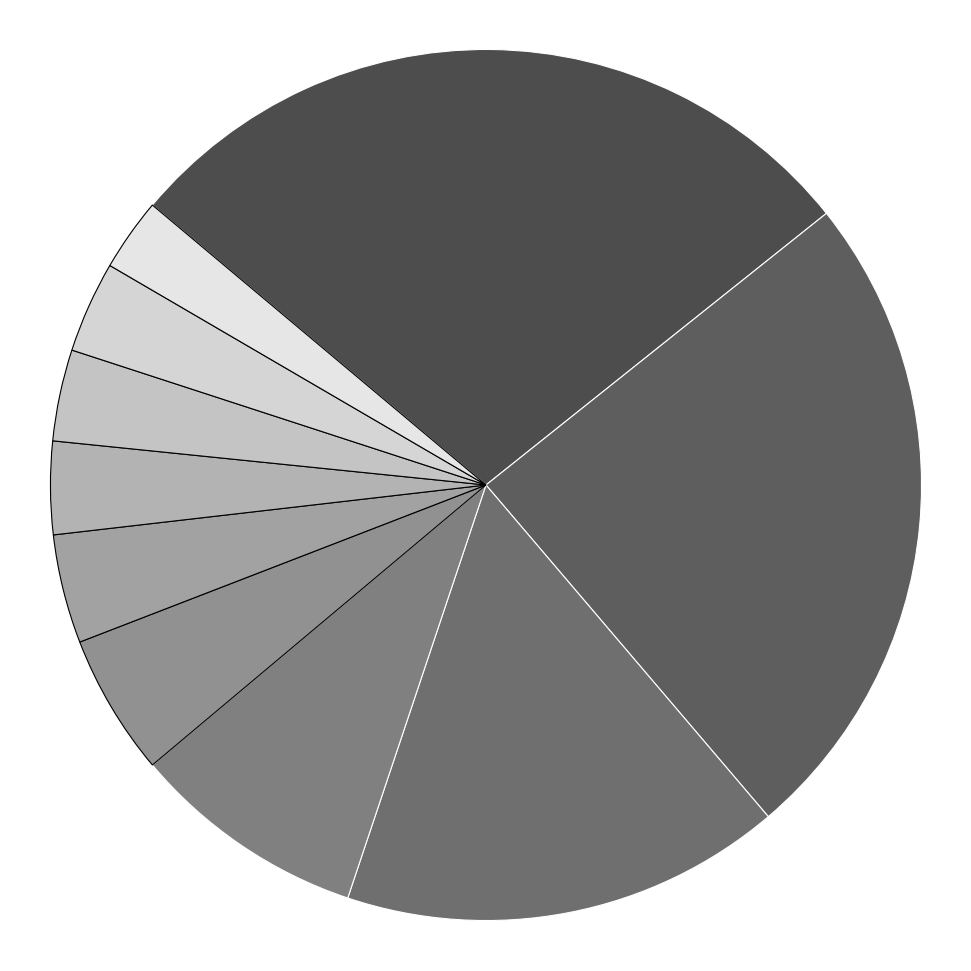

In [12]:
plt.rcParams.update({"font.size": 16})

path = '/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_2024_annual/inversion/posterior_ds.nc'
posterior_ds = xr.load_dataset(path)
areas = posterior_ds["AREA"]

# Extract sector names
sectors = [
    var
    for var in list(posterior_ds.keys())
    if ("EmisCH4" in var) 
       and not any(x in var for x in ["Total", "Excl", "Soil", "Lakes", "Seeps"])
]

sector_totals = [
    (posterior_ds[sector] * areas * 86400 * 365 * 1e-9).sum().item()
    for sector in sectors
]

# Clean up labels (drop the 'EmisCH4_' prefix)
sector_labels = [lbl.replace('EmisCH4_','') for lbl in sectors]
data = {sector_labels[i]: sector_totals[i] for i in range(len(sector_labels))}

# Combine Oil+Gas → OG, Wastewater+Landfills → Waste, as you did
if "Oil" in data and "Gas" in data:
    data["OG"] = data.pop("Oil") + data.pop("Gas")
if "Wastewater" in data and "Landfills" in data:
    data["Waste"] = data.pop("Wastewater") + data.pop("Landfills")

# ———————————————————————————————
# (2) Sort sectors by size (largest→smallest)
# ———————————————————————————————
data_sorted = dict(sorted(data.items(), key=lambda kv: kv[1], reverse=True))
sector_labels_sorted = list(data_sorted.keys())
values_sorted = list(data_sorted.values())

N = len(values_sorted)  # how many wedges

# (3) Build a grayscale ramp
min_gray = 0.3   # darkest we want (0.0 is pure black; 1.0 is pure white)
max_gray = 0.9   # lightest we want
grays = [
    str(min_gray + (max_gray - min_gray) * (i / (N - 1)))
    for i in range(N)
]


fig, ax = plt.subplots(figsize=(10, 10))
fig.patch.set_alpha(0)   # transparent figure background
ax.set_facecolor('none') # transparent axes background

wedges, texts = ax.pie(
    values_sorted,
    # labels=sector_labels_sorted,
    colors=grays,
    startangle=140,
    counterclock=False,
    wedgeprops={"edgecolor": "white", "linewidth": 0.8},
)

# Equal aspect ratio ensures that pie is drawn as a circle.
ax.axis('equal')  

for w in wedges[-6:]:
    w.set_edgecolor('black')
    w.set_linewidth(0.8)

plt.tight_layout()
plt.savefig('figures/piechart.png', dpi=1200, bbox_inches='tight', transparent=True)
plt.show()

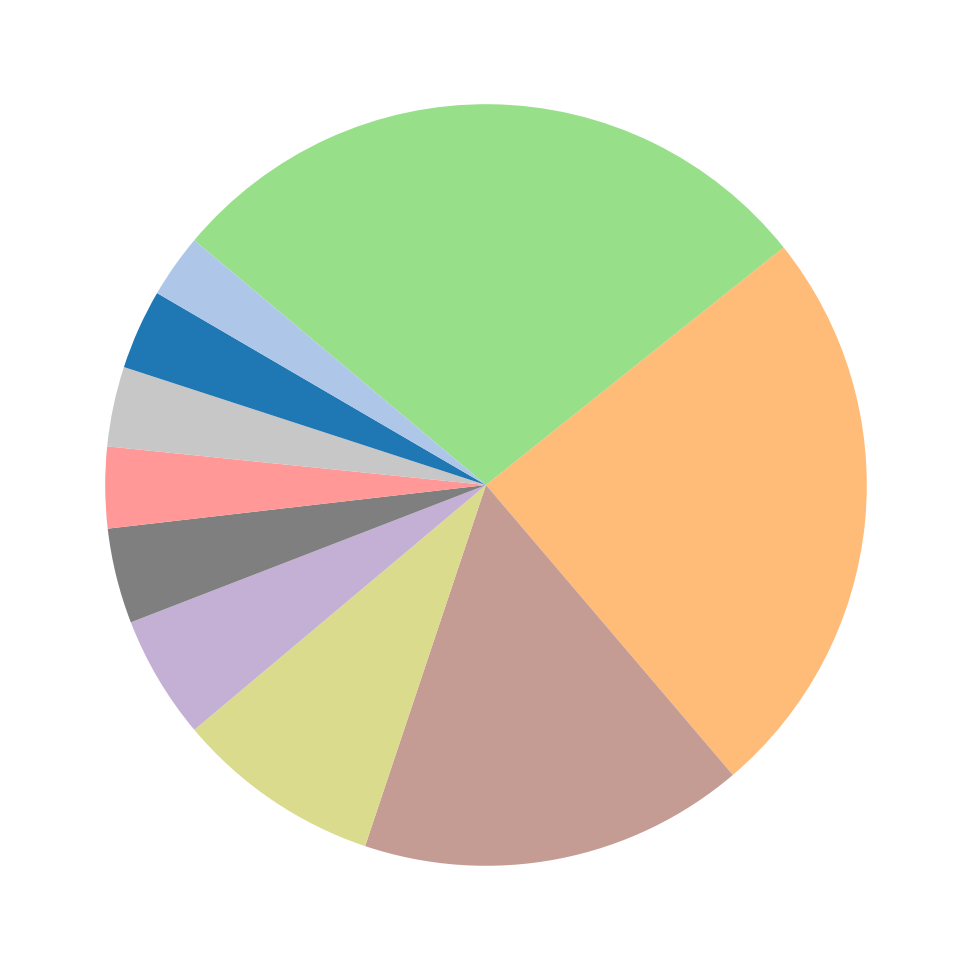

In [3]:
plt.rcParams.update({"font.size": 16})

num_colors = 20
cmap = plt.cm.get_cmap('tab20', num_colors)
all_colors = [cmap(i) for i in range(num_colors)]

sector_colors = {
    "Reservoirs": all_colors[0],
    "Termites": all_colors[1],
    # "Seeps": all_colors[15],
    "Wetlands": all_colors[5],
    "BiomassBurn": all_colors[7],
    "OtherAnth": all_colors[15],
    "Rice": all_colors[9],
    # "Wastewater": all_colors[11],
    # "Landfills": all_colors[11],
    "Livestock": all_colors[3],
    "Coal": all_colors[14],
    # "Gas": all_colors[17],
    # "Oil": all_colors[17],
}

sector_data = {}

path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_2024_annual/inversion/posterior_ds.nc'
posterior_ds = xr.load_dataset(path)
areas = posterior_ds["AREA"]

# Extract sector names
sectors = [
    var
    for var in list(posterior_ds.keys())
    if "EmisCH4" in var and not ("Total" in var or "Excl" in var or "Soil" in var or "Lakes" in var or "Seeps" in var)
]

# Extract data for each sector
sector_data = [
    (posterior_ds[sector] * areas * 86400 * 365 * 1e-9).sum().item() for sector in sectors
]

# Convert to a dictionary for plotting
sector_labels = [label.replace('EmisCH4_','') for label in sectors]
data = {sector: sector_data[i] for i, sector in enumerate(sector_labels)}

# Combine O/G
if "Oil" in data and "Gas" in data:
    combined_values = data["Oil"] + data["Gas"]
    data["OG"] = combined_values
    # remove the individual categories so they are not plotted separately
    del data["Oil"]
    del data["Gas"]

    sector_colors["OG"] = all_colors[17]
# combine waste
if "Wastewater" in data and "Landfills" in data:
    combined_values = data["Wastewater"] + data["Landfills"]
    data["Waste"] = combined_values
    # remove the individual categories so they are not plotted separately
    del data["Wastewater"]
    del data["Landfills"]

    sector_colors["Waste"] = all_colors[11]

# arrange slices by size
data_sorted = dict(sorted(data.items(), key=lambda item: item[1], reverse=True))
sector_labels_sorted = list(data_sorted.keys())
colors_sorted = [sector_colors[label] for label in sector_labels_sorted]

fig, ax = plt.subplots(figsize=(10, 10))
fig.patch.set_alpha(0)  # Make the figure background transparent
ax.set_facecolor('none') # Make the axes background transparent

colors = [sector_colors[label] for label in sector_labels_sorted]  # match colors to sectors

ax.pie(
    data_sorted.values(),
    # labels=data.keys(),
    colors=colors_sorted,
    # autopct='%1.1f%%',
    startangle=140,
    counterclock=False
)

plt.tight_layout()
plt.show()

[]

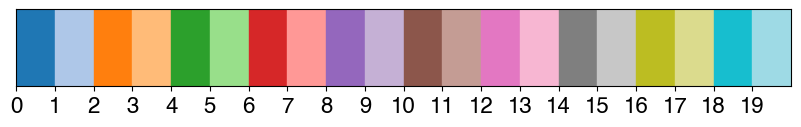

In [3]:
# show cmap colors
fig, ax = plt.subplots(figsize=(10, 1))

for i in range(num_colors):
    color = cmap(i)
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=color))
ax.set_xlim(0, num_colors)
ax.set_ylim(0, 1)
ax.set_xticks(np.arange(num_colors))
ax.set_xticklabels([f'{i}' for i in range(num_colors)])
ax.set_yticks([])
ax.set_yticklabels([])

In [8]:
total = sum(data_sorted.values())

# print each sector and its percent of the total
for sector, value in data_sorted.items():
    print(f"{sector:<12s}: {value:.1f} Tg, {(value / total) * 100:.1f}%")

Wetlands    : 161.8 Tg, 28.2%
Livestock   : 140.7 Tg, 24.5%
Waste       : 94.0 Tg, 16.4%
OG          : 50.2 Tg, 8.7%
Rice        : 30.1 Tg, 5.2%
Coal        : 23.2 Tg, 4.0%
BiomassBurn : 19.8 Tg, 3.4%
OtherAnth   : 19.5 Tg, 3.4%
Reservoirs  : 19.5 Tg, 3.4%
Termites    : 15.5 Tg, 2.7%


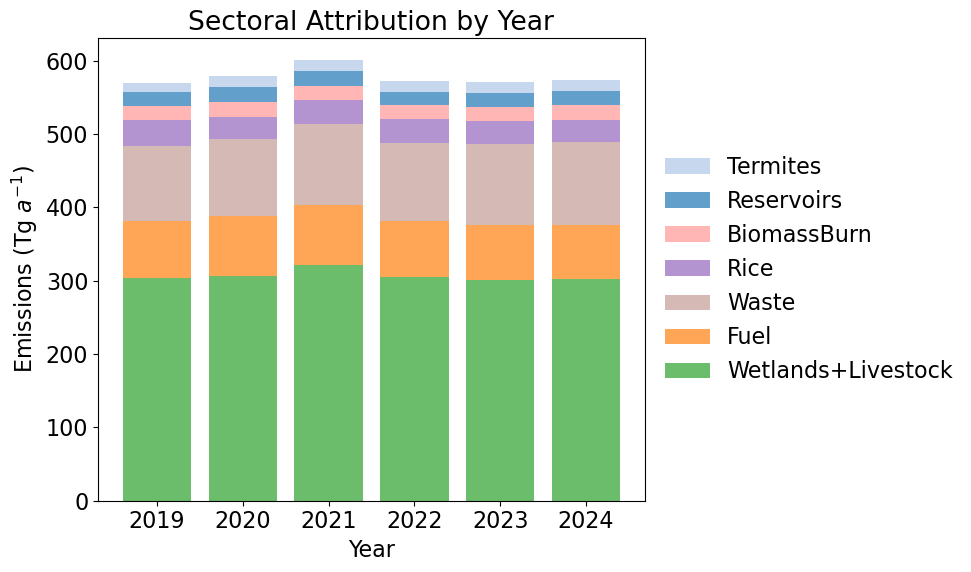

In [ ]:
plt.rcParams.update({"font.size": 16})

num_colors = 20
cmap = plt.cm.get_cmap('tab20', num_colors)
all_colors = [cmap(i) for i in range(num_colors)]

sector_colors = {
    "EmisCH4_Reservoirs": all_colors[0],
    "EmisCH4_Termites": all_colors[1],
    # "EmisCH4_Seeps": all_colors[5],
    # "EmisCH4_Wetlands": all_colors[12],
    "EmisCH4_BiomassBurn": all_colors[7],
    # "EmisCH4_OtherAnth": all_colors[6],
    "EmisCH4_Rice": all_colors[8],
    # "EmisCH4_Wastewater": all_colors[7],
    # "EmisCH4_Landfills": all_colors[9],
    # "EmisCH4_Livestock": all_colors[2],
    # "EmisCH4_Coal": all_colors[10],
    # "EmisCH4_Gas": all_colors[11],
    # "EmisCH4_Oil": all_colors[3],
}

years = [2019, 2020, 2021, 2022, 2023, 2024]
sector_data = {}

for year in years:
    if year == 2019:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual_ResMefix_2/inversion/posterior_ds.nc'
    else:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/inversion/posterior_ds.nc'
    
    posterior_ds = xr.load_dataset(path)
    areas = posterior_ds["AREA"]

    # Extract sector names
    sectors = [
        var
        for var in list(posterior_ds.keys())
        if "EmisCH4" in var and not ("Total" in var or "Excl" in var or "Soil" in var or "Lakes" in var or "Seeps" in var)
    ]

    # calc emissions for each sector for each year
    sector_data[year] = [
        (posterior_ds[sector] * areas * 86400 * 365 * 1e-9).sum().item() for sector in sectors
    ]

# Convert to a dictionary for plotting
original_sector_labels = [label.replace('EmisCH4_', '') for label in sectors]
data = {label: [sector_data[year][i] for year in years] for i, label in enumerate(original_sector_labels)}

# Combine wetlands and livestock
if "Wetlands" in data and "Livestock" in data:
    combined_values = [w + l for w, l in zip(data["Wetlands"], data["Livestock"])]
    data["Wetlands+Livestock"] = combined_values
    # remove the individual categories so they are not plotted separately
    del data["Wetlands"]
    del data["Livestock"]

    sector_colors["EmisCH4_Wetlands+Livestock"] = all_colors[4]
# Combine fuel
if "Oil" in data and "Gas" in data and "Coal" in data:
    combined_values = [o + g + c for o, g, c in zip(data["Oil"], data["Gas"], data["Coal"])]
    data["Fuel"] = combined_values
    # remove the individual categories so they are not plotted separately
    del data["Oil"]
    del data["Gas"]
    del data["Coal"]

    sector_colors["EmisCH4_Fuel"] = all_colors[2]
# combine waste
if "Wastewater" in data and "Landfills" in data and "OtherAnth" in data:
    combined_values = [w + l + o for w, l, o in zip(data["Wastewater"], data["Landfills"], data["OtherAnth"])]
    data["Waste"] = combined_values
    # remove the individual categories so they are not plotted separately
    del data["Wastewater"]
    del data["Landfills"]
    del data["OtherAnth"]

    sector_colors["EmisCH4_Waste"] = all_colors[11]

# Plot
# Set order
order = [
    "Wetlands+Livestock",
    "Fuel",
    "Waste",
    "Rice",
    "BiomassBurn",
    "Reservoirs",
    "Termites",
]
fig, ax = plt.subplots(figsize=(10, 6))
bottom = np.zeros(len(years))

# for sector, values in data.items():
for sector in order:
    values = data[sector]
    ax.bar(
        years,
        values,
        label=sector,
        bottom=bottom,
        alpha=0.7,
        color=sector_colors[f"EmisCH4_{sector}"]
    )
    bottom += np.array(values)

ax.set_xlabel("Year")
ax.set_ylabel("Emissions (Tg $a^{-1}$)")
ax.set_title("Sectoral Attribution by Year")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
plt.xticks(years)
plt.tight_layout()
plt.show()

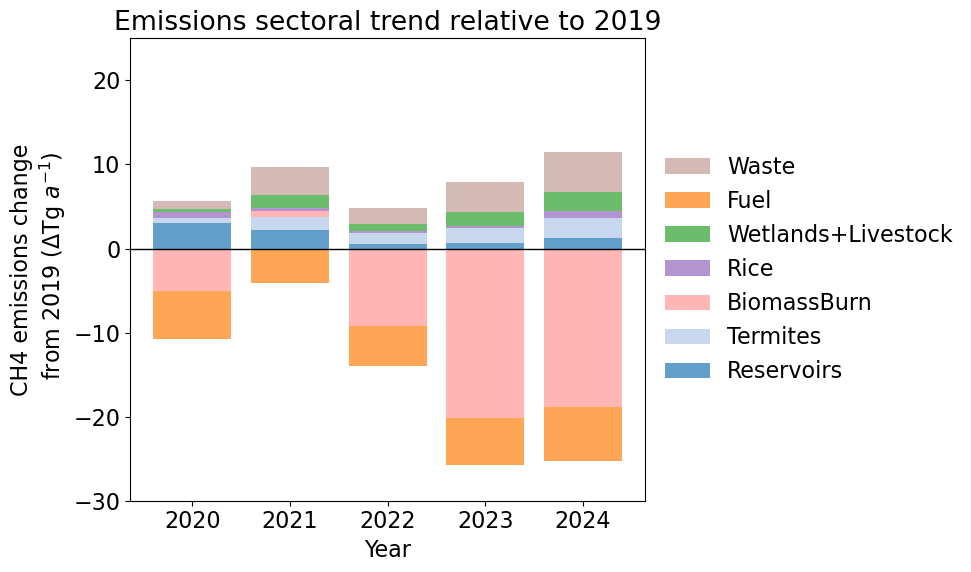

In [7]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

num_colors = 20
cmap = plt.cm.get_cmap('tab20', num_colors)
all_colors = [cmap(i) for i in range(num_colors)]

sector_colors = {
    "EmisCH4_Reservoirs": all_colors[0],
    "EmisCH4_Termites": all_colors[1],
    "EmisCH4_BiomassBurn": all_colors[7],
    "EmisCH4_Rice": all_colors[8],
    "EmisCH4_Wetlands+Livestock": all_colors[4],
    "EmisCH4_Fuel": all_colors[2],
    "EmisCH4_Waste": all_colors[11]
}

years_all = [2019, 2020, 2021, 2022, 2023, 2024]  # Includes 2019 for reference
years_plot = [2020, 2021, 2022, 2023, 2024]  # Only years to be plotted

# Compute absolute change relative to 2019
baseline_2019 = {sector: sector_data[2019][i] for i, sector in enumerate(data)}
data_relative = {sector: [sector_data[year][i] - baseline_2019[sector] for year in years_plot] for i, sector in enumerate(data)}

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

# Create separate stacks for positive and negative changes
bottom_positive = np.zeros(len(years_plot))
bottom_negative = np.zeros(len(years_plot))

sector_handles = {}  # one handle per sector to avoid duplicates in legend

for i, (sector, values) in enumerate(data_relative.items()):
    values = np.array(values)

    # Identify positive and negative changes to avoid bars that overlap 0
    pos_values = np.where(values > 0, values, 0)
    neg_values = np.where(values < 0, values, 0)

    # Stack positives together
    bars_pos = ax.bar(years_plot, pos_values, bottom=bottom_positive, alpha=0.7, color=sector_colors[f"EmisCH4_{sector}"])
    bottom_positive += pos_values

    # Stack negatives together
    bars_neg = ax.bar(years_plot, neg_values, bottom=bottom_negative, alpha=0.7, color=sector_colors[f"EmisCH4_{sector}"])
    bottom_negative += neg_values  # Update the negative stack

    # Store one handle per sector to avoid duplicates in legend
    if sector not in sector_handles:
        sector_handles[sector] = bars_pos[0] if any(pos_values) else bars_neg[0]

ax.axhline(0, color='black', linewidth=1)
ax.set_xlabel("Year")
ax.set_ylabel("CH4 emissions change\n from 2019 ($\\Delta$Tg $a^{-1}$)")
ax.set_title("Emissions sectoral trend relative to 2019")
ax.set_ylim(-30, 25)

# one handle per sector for legend and reverse order
handles = list(sector_handles.values())[::-1]
labels = list(sector_handles.keys())[::-1]

ax.legend(handles, labels, loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)

plt.rcParams.update({"font.size": 16})
plt.xticks(years_plot)
plt.tight_layout()

plt.show()


## Old

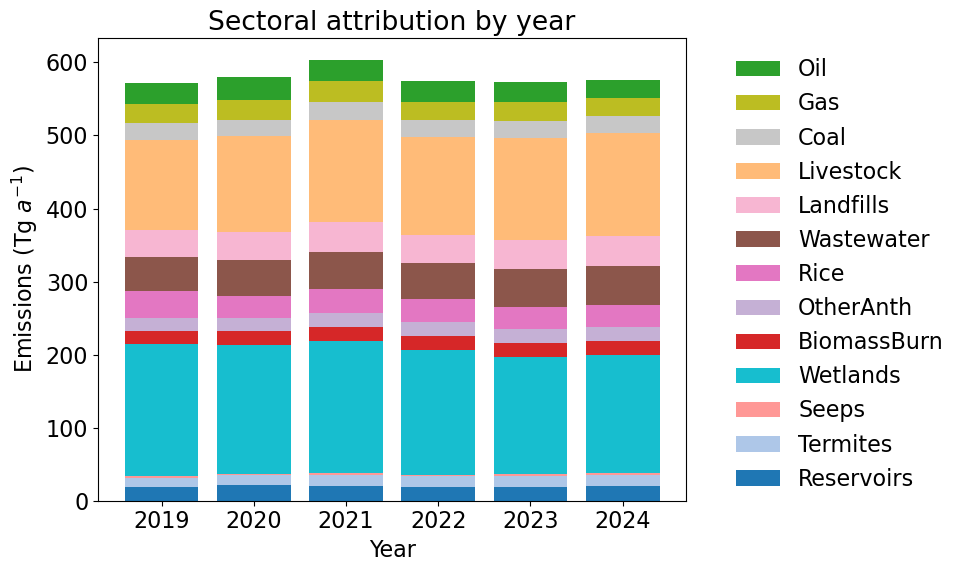

In [4]:
plt.rcParams.update({"font.size": 16})

num_colors = 14
cmap = plt.cm.get_cmap('tab20', num_colors)
all_colors = [cmap(i) for i in range(num_colors)]

sector_colors = {
    "EmisCH4_Reservoirs": all_colors[0],
    "EmisCH4_Termites": all_colors[1],
    "EmisCH4_Seeps": all_colors[5],
    "EmisCH4_Wetlands": all_colors[12],
    "EmisCH4_BiomassBurn": all_colors[4],
    "EmisCH4_OtherAnth": all_colors[6],
    "EmisCH4_Rice": all_colors[8],
    "EmisCH4_Wastewater": all_colors[7],
    "EmisCH4_Landfills": all_colors[9],
    "EmisCH4_Livestock": all_colors[2],
    "EmisCH4_Coal": all_colors[10],
    "EmisCH4_Gas": all_colors[11],
    "EmisCH4_Oil": all_colors[3],
}

years = [2019, 2020, 2021, 2022, 2023, 2024]
sector_data = {}

for year in years:
    # set directory
    if year == 2019:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual_ResMefix_2/inversion/posterior_ds.nc'
    else:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/inversion/posterior_ds.nc'
    posterior_ds = xr.load_dataset(path)
    areas = posterior_ds["AREA"]

    # Extract sector names
    sectors = [
        var
        for var in list(posterior_ds.keys())
        if "EmisCH4" in var and not ("Total" in var or "Excl" in var or "Soil" in var or "Lakes" in var)
    ]

    # Extract data for each sector
    sector_data[year] = [
        (posterior_ds[sector] * areas * 86400 * 365 * 1e-9).sum().item() for sector in sectors
    ]

# Convert to a dictionary for plotting
sector_labels = sectors
sector_labels = [label.replace('EmisCH4_','') for label in sector_labels]
data = {sector: [sector_data[year][i] for year in years] for i, sector in enumerate(sector_labels)}

fig, ax = plt.subplots(figsize=(10, 6))
bottom = np.zeros(len(years))

for i, (sector, values) in enumerate(data.items()):
    ax.bar(
        years,
        values,
        label=sector,
        bottom=bottom,
        color=sector_colors[f"EmisCH4_{sector}"]  # Use the assigned color
    )
    bottom += np.array(values)

ax.set_xlabel("Year")
ax.set_ylabel("Emissions (Tg $a^{-1}$)")
ax.set_title("Sectoral attribution by year")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
plt.xticks(years)
plt.tight_layout()

plt.show()


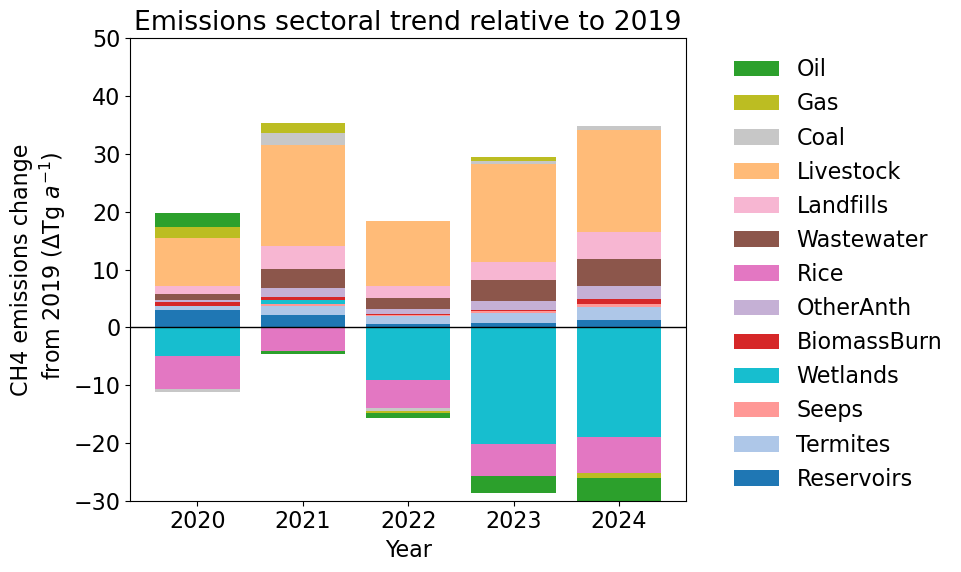

In [5]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

plt.rcParams.update({"font.size": 16})
num_colors = 14
cmap = plt.cm.get_cmap('tab20', num_colors)
all_colors = [cmap(i) for i in range(num_colors)]

sector_colors = {
    "EmisCH4_Reservoirs": all_colors[0],
    "EmisCH4_Termites": all_colors[1],
    "EmisCH4_Seeps": all_colors[5],
    "EmisCH4_Wetlands": all_colors[12],
    "EmisCH4_BiomassBurn": all_colors[4],
    "EmisCH4_OtherAnth": all_colors[6],
    "EmisCH4_Rice": all_colors[8],
    "EmisCH4_Wastewater": all_colors[7],
    "EmisCH4_Landfills": all_colors[9],
    "EmisCH4_Livestock": all_colors[2],
    "EmisCH4_Coal": all_colors[10],
    "EmisCH4_Gas": all_colors[11],
    "EmisCH4_Oil": all_colors[3],
}

years_all = [2019, 2020, 2021, 2022, 2023, 2024]  # Includes 2019 for reference
years_plot = [2020, 2021, 2022, 2023, 2024]  # Only years to be plotted
sector_data = {}

for year in years_all:
    # Set directory
    if year == 2019:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual_ResMefix_2/inversion/posterior_ds.nc'
    else:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/inversion/posterior_ds.nc'
    posterior_ds = xr.load_dataset(path)
    areas = posterior_ds["AREA"]

    # Extract sector names
    sectors = [
        var
        for var in list(posterior_ds.keys())
        if "EmisCH4" in var and not ("Total" in var or "Excl" in var or "Soil" in var or "Lakes" in var)
    ]

    # Extract data for each sector
    sector_data[year] = [
        (posterior_ds[sector] * areas * 86400 * 365 * 1e-9).sum().item() for sector in sectors
    ]

# Convert to a dictionary for plotting
sector_labels = sectors
sector_labels = [label.replace('EmisCH4_', '') for label in sector_labels]

# Compute absolute change relative to 2019
baseline_2019 = {sector: sector_data[2019][i] for i, sector in enumerate(sector_labels)}
data = {sector: [sector_data[year][i] - baseline_2019[sector] for year in years_plot] for i, sector in enumerate(sector_labels)}

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

# Create separate stacks for positive and negative changes
bottom_positive = np.zeros(len(years_plot))
bottom_negative = np.zeros(len(years_plot))

sector_handles = {}  # one handle per sector to avoid duplicates in legend

for i, (sector, values) in enumerate(data.items()):
    values = np.array(values)

    # Identify positive and negative changes to avoid bars that overlap 0
    pos_values = np.where(values > 0, values, 0)
    neg_values = np.where(values < 0, values, 0)

    # Stack positives together
    bars_pos = ax.bar(years_plot, pos_values, bottom=bottom_positive, color=sector_colors[f"EmisCH4_{sector}"])
    bottom_positive += pos_values

    # Stack negatives together
    bars_neg = ax.bar(years_plot, neg_values, bottom=bottom_negative, color=sector_colors[f"EmisCH4_{sector}"])
    bottom_negative += neg_values  # Update the negative stack

    # Store one handle per sector to avoid duplicates in legend
    if sector not in sector_handles:
        sector_handles[sector] = bars_pos[0] if any(pos_values) else bars_neg[0]

ax.axhline(0, color='black', linewidth=1)
ax.set_xlabel("Year")
ax.set_ylabel("CH4 emissions change\n from 2019 ($\\Delta$Tg $a^{-1}$)")
ax.set_title("Emissions sectoral trend relative to 2019")
ax.set_ylim(-30, 50)

# one handle per sector for legend and reverse order
handles = list(sector_handles.values())[::-1]
labels = list(sector_handles.keys())[::-1]

ax.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

plt.rcParams.update({"font.size": 16})
plt.xticks(years_plot)
plt.tight_layout()

plt.show()


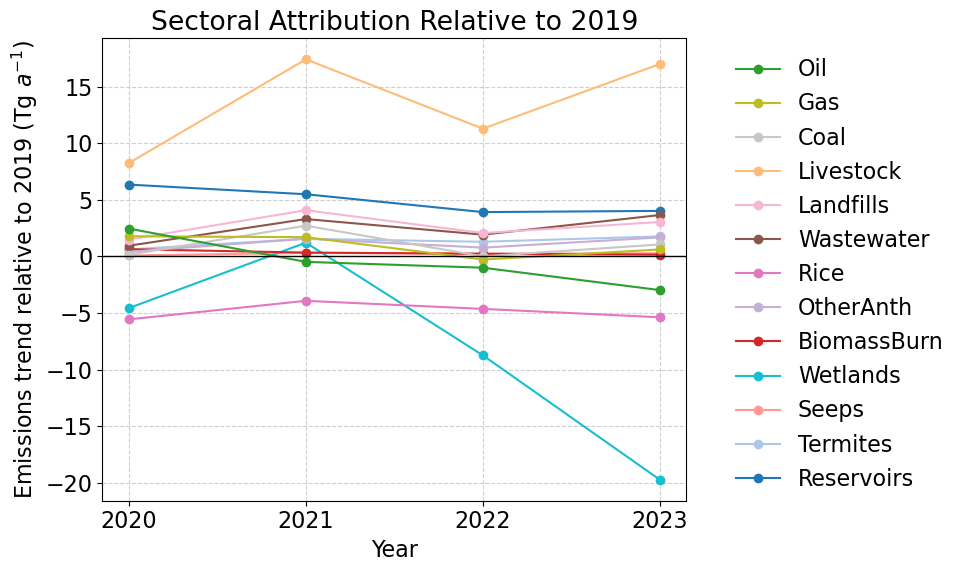

In [34]:
# Plot lines instead of bars
fig, ax = plt.subplots(figsize=(10, 6))

sector_handles = {}  # Store one handle per sector for the legend

for sector, values in data.items():
    values = np.array(values)

    # Plot the line for each sector
    line, = ax.plot(years_plot, values, marker='o', linestyle='-', color=sector_colors[f"EmisCH4_{sector}"], label=sector)
    
    # Store one handle per sector for the legend
    sector_handles[sector] = line

ax.axhline(0, color='black', linewidth=1)  # Reference line at zero
ax.set_xlabel("Year")
ax.set_ylabel("Emissions trend relative to 2019 (Tg $a^{-1}$)")
ax.set_title("Sectoral Attribution Relative to 2019")

# Reverse legend order
handles = list(sector_handles.values())[::-1]
labels = list(sector_handles.keys())[::-1]

ax.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

plt.rcParams.update({"font.size": 16})
plt.xticks(years_plot)
plt.grid(True, linestyle='--', alpha=0.6)  # Add a grid for better readability
plt.tight_layout()

plt.show()